In [2]:
import pandas as pd

df = pd.read_csv("../data/emotion_classify_Data.csv")
df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [3]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    # text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["clean_text"] = df["Comment"].apply(clean_text)

In [4]:
df.head()

,Comment,Emotion,clean_text
0,i seriously hate one subject to death but now ...,fear,i seriously hate one subject to death but now ...
1,im so full of life i feel appalled,anger,im so full of life i feel appalled
2,i sit here to write i start to dig out my feel...,fear,i sit here to write i start to dig out my feel...
3,ive been really angry with r and i feel like a...,joy,ive been really angry with r and i feel like a...
4,i feel suspicious if there is no one outside l...,fear,i feel suspicious if there is no one outside l...


In [5]:
from sentence_transformers import SentenceTransformer

# model = SentenceTransformer('all-MiniLM-L6-v2')
model = SentenceTransformer('j-hartmann/emotion-english-distilroberta-base')

embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batches:   0%|          | 0/186 [00:00<?, ?it/s]

In [6]:
texts = df["clean_text"].tolist()
embeddings = model.encode(texts, show_progress_bar=True)

Batches:   0%|          | 0/186 [00:00<?, ?it/s]

In [7]:
print(len(embeddings))
print(len(embeddings[0]))

5923
768


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)


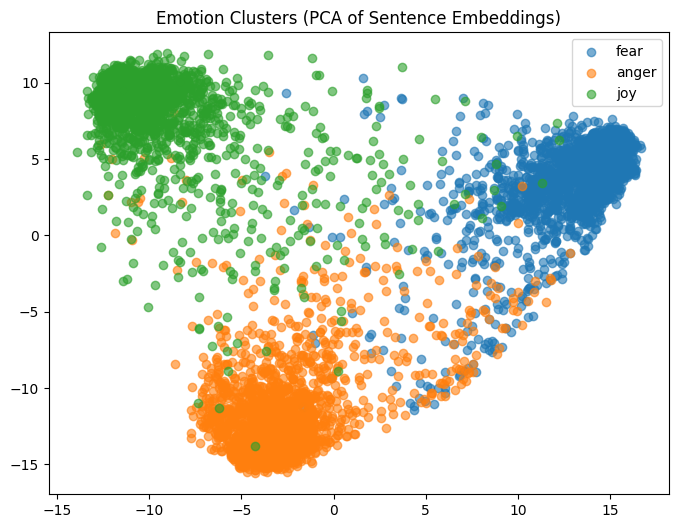

In [9]:
import matplotlib.pyplot as plt

labels = df["Emotion"]

plt.figure(figsize=(8,6))

for emotion in labels.unique():
    idx = labels == emotion
    plt.scatter(reduced[idx, 0], reduced[idx, 1], label=emotion, alpha=0.6)

plt.legend()
plt.title("Emotion Clusters (PCA of Sentence Embeddings)")
plt.show()

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5,
    max_iter=1000
)

reduced_tsne = tsne.fit_transform(embeddings)

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(embeddings)

In [13]:
import pandas as pd

df["cluster"] = clusters

print(pd.crosstab(df["Emotion"], df["cluster"]))

cluster     0     1    2
Emotion                 
anger    1826    12  157
fear       15  1605  315
joy      1931    15   47


In [14]:
pd.crosstab(df["Emotion"], df["cluster"], normalize='index')

cluster,0,1,2
Emotion,,,
anger,0.915288,0.006015,0.078697
fear,0.007752,0.829457,0.162791
joy,0.968891,0.007526,0.023583


In [15]:
df_h = pd.read_csv("../data/Hinglish_classify_Data.csv")

In [16]:
df_en = df.copy()

In [17]:
df_h["clean_text"] = df_h["Comment"].apply(clean_text)

In [18]:
def run_pipeline(df):
    texts = df["clean_text"].tolist()
    embeddings = model.encode(texts)

    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(embeddings)

    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(embeddings)

    return embeddings, reduced, clusters

In [19]:
emb_en, tsne_en, clus_en = run_pipeline(df_en)
emb_h, tsne_h, clus_h = run_pipeline(df_h)


In [20]:
df_en["cluster"] = clus_en
df_h["cluster"] = clus_h

In [21]:
print("English:")
print(pd.crosstab(df_en["Emotion"], df_en["cluster"]))

print("\nHinglish:")
print(pd.crosstab(df_h["Emotion"], df_h["cluster"]))

English:
cluster     0     1    2
Emotion                 
anger    1826    12  157
fear       15  1605  315
joy      1931    15   47

Hinglish:
cluster   0   1   2
Emotion            
anger    66  34   0
fear     58  38   4
joy      17  45  38


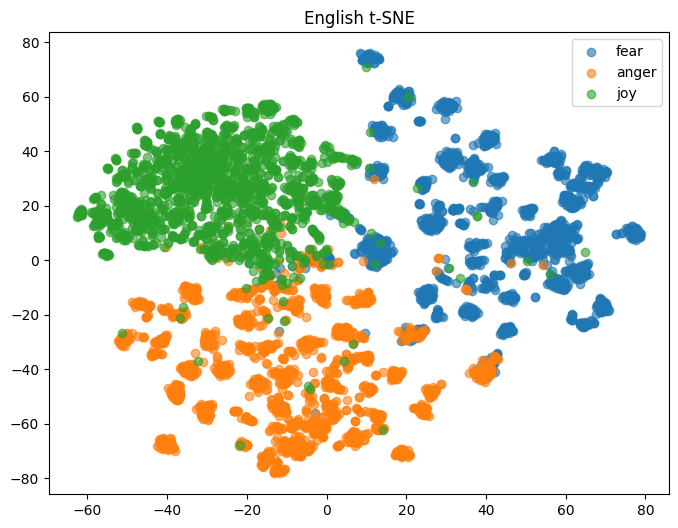

In [22]:
labels = df_en["Emotion"]

plt.figure(figsize=(8,6))

for emotion in labels.unique():
    idx = labels == emotion
    plt.scatter(
        tsne_en[idx, 0],
        tsne_en[idx, 1],
        label=emotion,
        alpha=0.6
    )

plt.legend()
plt.title("English t-SNE")
plt.show()

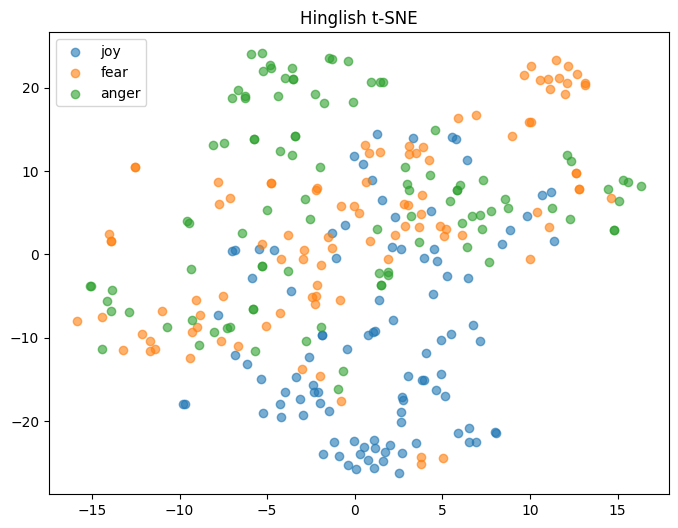

In [23]:
import matplotlib.pyplot as plt

labels = df_h["Emotion"]

plt.figure(figsize=(8,6))

for emotion in labels.unique():
    idx = labels == emotion
    plt.scatter(
        tsne_h[idx, 0],
        tsne_h[idx, 1],
        label=emotion,
        alpha=0.6
    )

plt.legend()
plt.title("Hinglish t-SNE")
plt.show()

In [24]:
from sklearn.metrics import silhouette_score

print("English Silhouette:", silhouette_score(emb_en, clus_en))
print("Hinglish Silhouette:", silhouette_score(emb_h, clus_h))

English Silhouette: 0.29715201258659363
Hinglish Silhouette: 0.12564091384410858


In [25]:
df_en_small = df_en.sample(n=300, random_state=42)

emb_en_s, tsne_en_s, clus_en_s = run_pipeline(df_en_small)

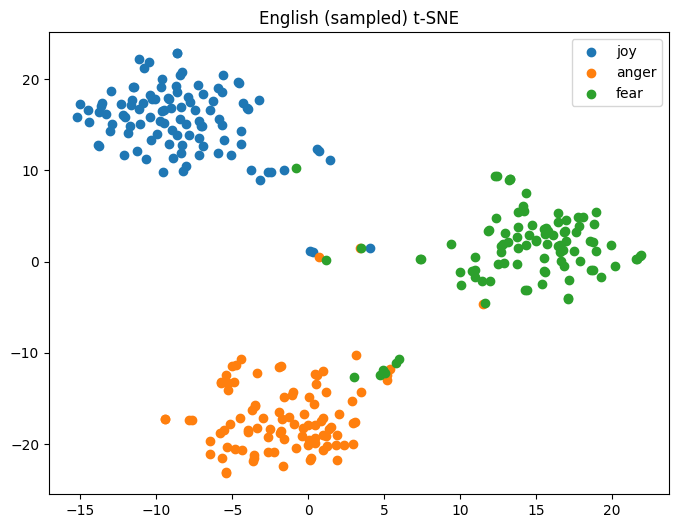

In [26]:
labels = df_en_small["Emotion"]

plt.figure(figsize=(8,6))

for emotion in labels.unique():
    idx = labels == emotion
    plt.scatter(tsne_en_s[idx, 0], tsne_en_s[idx, 1], label=emotion)

plt.legend()
plt.title("English (sampled) t-SNE")
plt.show()

In [27]:
from sklearn.metrics import silhouette_score

print("English:", silhouette_score(emb_en_s, clus_en_s))
print("Hinglish:", silhouette_score(emb_h, clus_h))

English: 0.5047158002853394
Hinglish: 0.12564091384410858
